In [136]:
!unzip dataset.zip

Archive:  dataset.zip
replace dataset/spiral/testing/healthy/V01HE01.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: dataset/spiral/testing/healthy/V01HE01.png  
  inflating: dataset/spiral/testing/healthy/V02HE01.png  
  inflating: dataset/spiral/testing/healthy/V03HE1.png  
  inflating: dataset/spiral/testing/healthy/V04HE01.png  
  inflating: dataset/spiral/testing/healthy/V05HE01.png  
  inflating: dataset/spiral/testing/healthy/V06HE01.png  
  inflating: dataset/spiral/testing/healthy/V07HE01.png  
  inflating: dataset/spiral/testing/healthy/V08HE01.png  
  inflating: dataset/spiral/testing/healthy/V09HE01.png  
  inflating: dataset/spiral/testing/healthy/V10HE01.png  
  inflating: dataset/spiral/testing/healthy/V11HE01.png  
  inflating: dataset/spiral/testing/healthy/V55HE12.png  
  inflating: dataset/spiral/testing/healthy/V55HE13.png  
  inflating: dataset/spiral/testing/healthy/V55HE14.png  
  inflating: dataset/spiral/testing/healthy/V55HE15.png  
  inflating: data

# Libraries

In [145]:
import os
import cv2
import tensorflow as tf
from matplotlib import pyplot as plt

## Initial data exploration

Write code to load a few sample images, display them, check image dimensions, color channels, and get a count of images per class.


Displaying sample images from: spiral/training/healthy


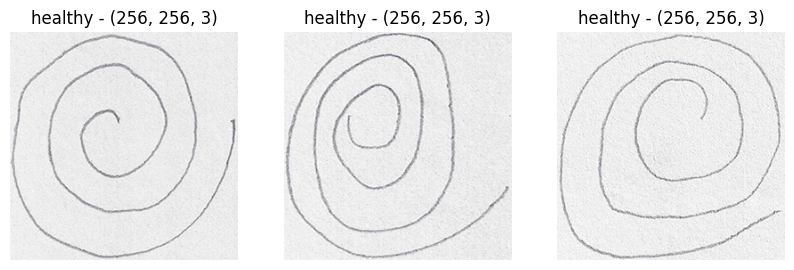

Displaying sample images from: spiral/training/parkinson


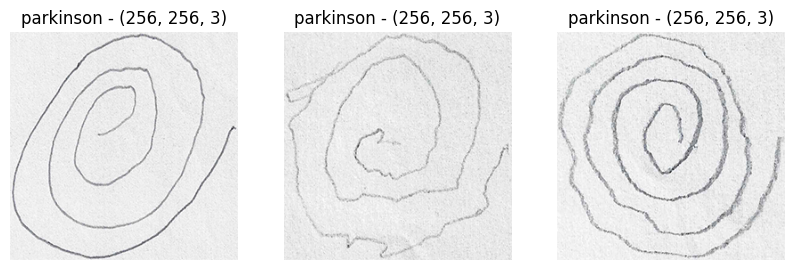

Displaying sample images from: wave/training/healthy


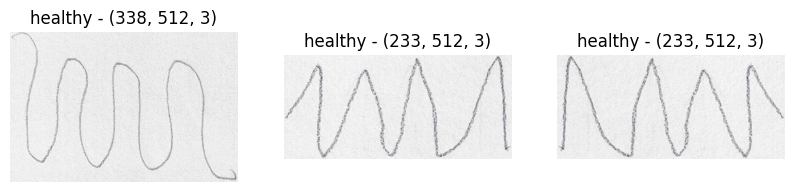

Displaying sample images from: wave/training/parkinson


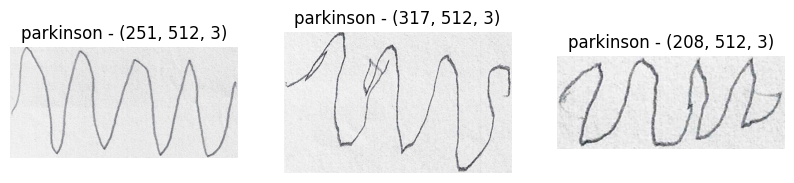


Image Counts:
Dataset: spiral
  training:
    healthy: 36
    parkinson: 36
  testing:
    healthy: 15
    parkinson: 15
Dataset: wave
  training:
    healthy: 36
    parkinson: 36
  testing:
    healthy: 15
    parkinson: 15


In [138]:
# Define the base directory
base_dir = 'dataset'

# Define the subdirectories for training and testing, and the classes
subdirs = ['training', 'testing']
classes = ['healthy', 'parkinson']
datasets = ['spiral', 'wave']

# Dictionary to store image counts per class
image_counts = {}

# Iterate through datasets, subdirectories, and classes to list images and count
for dataset in datasets:
    image_counts[dataset] = {}
    for subdir in subdirs:
        image_counts[dataset][subdir] = {}
        for class_name in classes:
            # Construct the path to the current class directory
            class_dir = os.path.join(base_dir, dataset, subdir, class_name)
            # List all files in the directory
            image_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith('.png')]
            # Store the count
            image_counts[dataset][subdir][class_name] = len(image_files)

            # Display a few sample images from the training set of each class
            if subdir == 'training':
                print(f"Displaying sample images from: {dataset}/{subdir}/{class_name}")
                plt.figure(figsize=(10, 5))
                for i in range(min(3, len(image_files))): # Display up to 3 images
                    img_path = image_files[i]
                    img = cv2.imread(img_path)
                    # OpenCV reads images as BGR, convert to RGB for matplotlib
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.subplot(1, 3, i + 1)
                    plt.imshow(img_rgb)
                    plt.title(f"{class_name} - {img_rgb.shape}") # Display shape (height, width, channels)
                    plt.axis('off')
                plt.show()

# Print the image counts
print("\nImage Counts:")
for dataset in datasets:
    print(f"Dataset: {dataset}")
    for subdir in subdirs:
        print(f"  {subdir}:")
        for class_name in classes:
            count = image_counts[dataset][subdir][class_name]
            print(f"    {class_name}: {count}")

# Data Loading

In [139]:
# Define image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Define the base directory
base_dir = 'dataset'

# Load spiral datasets
spiral_train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'spiral', 'training'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

spiral_test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'spiral', 'testing'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle test data
)

# Load wave datasets
wave_train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'wave', 'training'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

wave_test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=os.path.join(base_dir, 'wave', 'testing'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle test data
)

print("\nSpiral Training Dataset:")
print(spiral_train_ds)
print("\nSpiral Test Dataset:")
print(spiral_test_ds)
print("\nWave Training Dataset:")
print(wave_train_ds)
print("\nWave Test Dataset:")
print(wave_test_ds)

Found 72 files belonging to 2 classes.
Found 30 files belonging to 2 classes.
Found 72 files belonging to 2 classes.
Found 30 files belonging to 2 classes.

Spiral Training Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Spiral Test Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Wave Training Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Wave Test Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


# Normalization

In [140]:
# Apply normalization to the datasets directly
normalized_spiral_train_ds = spiral_train_ds.map(lambda image, label: (tf.cast(image, tf.float32) / 255.0, label))
normalized_spiral_test_ds = spiral_test_ds.map(lambda image, label: (tf.cast(image, tf.float32) / 255.0, label))
normalized_wave_train_ds = wave_train_ds.map(lambda image, label: (tf.cast(image, tf.float32) / 255.0, label))
normalized_wave_test_ds = wave_test_ds.map(lambda image, label: (tf.cast(image, tf.float32) / 255.0, label))


print("\nNormalized Spiral Training Dataset:")
print(normalized_spiral_train_ds)
print("\nNormalized Spiral Test Dataset:")
print(normalized_spiral_test_ds)
print("\nNormalized Wave Training Dataset:")
print(normalized_wave_train_ds)
print("\nNormalized Wave Test Dataset:")
print(normalized_wave_test_ds)


Normalized Spiral Training Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Normalized Spiral Test Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Normalized Wave Training Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Normalized Wave Test Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


# Data Splitting

In [141]:
# Define the split ratio for the validation set
validation_split = 0.2
seed = 42 # for reproducible split

# Calculate the number of validation samples
spiral_train_size = tf.data.experimental.cardinality(normalized_spiral_train_ds).numpy() * BATCH_SIZE
spiral_val_size = int(spiral_train_size * validation_split)

wave_train_size = tf.data.experimental.cardinality(normalized_wave_train_ds).numpy() * BATCH_SIZE
wave_val_size = int(wave_train_size * validation_split)


# Create the validation datasets
spiral_val_ds = normalized_spiral_train_ds.take(spiral_val_size // BATCH_SIZE)
spiral_train_ds = normalized_spiral_train_ds.skip(spiral_val_size // BATCH_SIZE)

wave_val_ds = normalized_wave_train_ds.take(wave_val_size // BATCH_SIZE)
wave_train_ds = normalized_wave_train_ds.skip(wave_val_size // BATCH_SIZE)

print("\nSpiral Training Dataset after split:")
print(spiral_train_ds)
print("\nSpiral Validation Dataset:")
print(spiral_val_ds)
print("\nWave Training Dataset after split:")
print(wave_train_ds)
print("\nWave Validation Dataset:")
print(wave_val_ds)


Spiral Training Dataset after split:
<_SkipDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Spiral Validation Dataset:
<_TakeDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Wave Training Dataset after split:
<_SkipDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Wave Validation Dataset:
<_TakeDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


# Data Augmentation

In [142]:
# Implement Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

# Apply data augmentation only to the training datasets
augmented_spiral_train_ds = normalized_spiral_train_ds.map(lambda x, y: (data_augmentation(x), y))
augmented_wave_train_ds = normalized_wave_train_ds.map(lambda x, y: (data_augmentation(x), y))

# Keep the validation and test datasets as they are (normalized)
final_spiral_val_ds = spiral_val_ds
final_spiral_test_ds = normalized_spiral_test_ds
final_wave_val_ds = wave_val_ds
final_wave_test_ds = normalized_wave_test_ds


print("\nAugmented Spiral Training Dataset:")
print(augmented_spiral_train_ds)
print("\nAugmented Wave Training Dataset:")
print(augmented_wave_train_ds)
print("\nFinal Spiral Validation Dataset:")
print(final_spiral_val_ds)
print("\nFinal Spiral Test Dataset:")
print(final_spiral_test_ds)
print("\nFinal Wave Validation Dataset:")
print(final_wave_val_ds)
print("\nFinal Wave Test Dataset:")
print(final_wave_test_ds)


Augmented Spiral Training Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Augmented Wave Training Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Final Spiral Validation Dataset:
<_TakeDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Final Spiral Test Dataset:
<_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Final Wave Validation Dataset:
<_TakeDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Final Wave Test Dataset:
<_MapDataset element_spec=(TensorSpec(

# Configure Data Pipeline

In [143]:
# Configure Data Pipeline Performance
AUTOTUNE = tf.data.AUTOTUNE

augmented_spiral_train_ds = augmented_spiral_train_ds.cache().repeat(EPOCHS).prefetch(buffer_size=AUTOTUNE)
final_spiral_val_ds = final_spiral_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
final_spiral_test_ds = final_spiral_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

augmented_wave_train_ds = augmented_wave_train_ds.cache().repeat(EPOCHS).prefetch(buffer_size=AUTOTUNE)
final_wave_val_ds = final_wave_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
final_wave_test_ds = final_wave_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\nConfigured Spiral Training Dataset:")
print(augmented_spiral_train_ds)
print("\nConfigured Spiral Validation Dataset:")
print(final_spiral_val_ds)
print("\nConfigured Spiral Test Dataset:")
print(final_spiral_test_ds)
print("\nConfigured Wave Training Dataset:")
print(augmented_wave_train_ds)
print("\nConfigured Wave Validation Dataset:")
print(final_wave_val_ds)
print("\nConfigured Wave Test Dataset:")
print(final_wave_test_ds)


Configured Spiral Training Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Configured Spiral Validation Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Configured Spiral Test Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Configured Wave Training Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Configured Wave Validation Dataset:
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

Configured Wave Test Da

# Verification of Processed Data

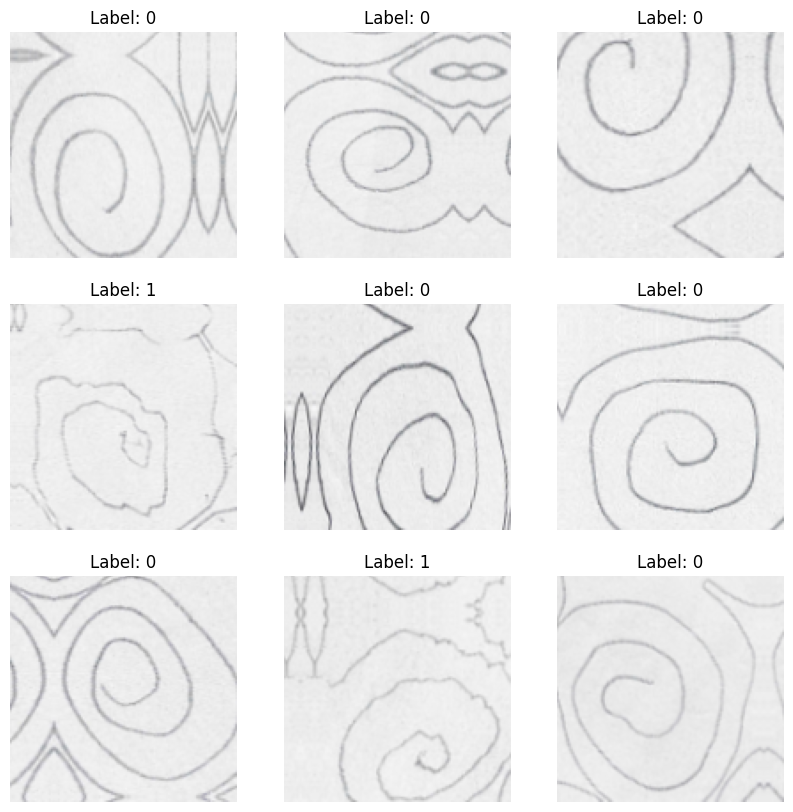

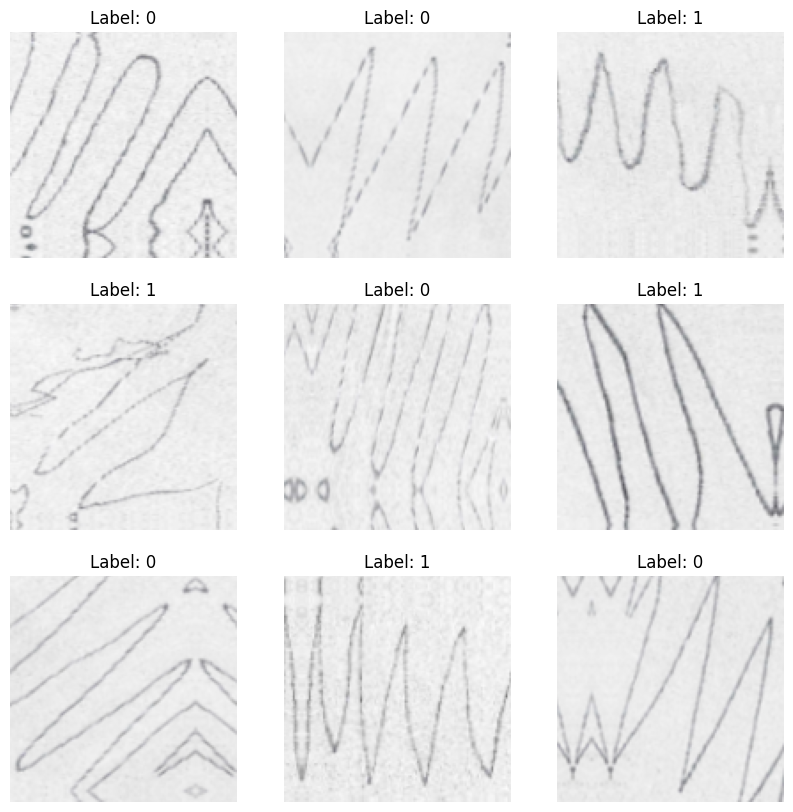

In [144]:
# Verify Processed Data: Visualize a batch of augmented training data
plt.figure(figsize=(10, 10))
for images, labels in augmented_spiral_train_ds.take(1):
    for i in range(min(9, images.shape[0])): # Display up to 9 images from the batch
        ax = plt.subplot(3, 3, i + 1)
        # Display grayscale images (single channel)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        # Access the scalar value of the label tensor
        plt.title(f"Label: {int(labels[i].numpy().item())}")
        plt.axis("off")
plt.show()

plt.figure(figsize=(10, 10))
for images, labels in augmented_wave_train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(f"Label: {int(labels[i].numpy().item())}")
        plt.axis("off")
plt.show()

# Task
Generate augmented images from a given set of images using `ImageDataGenerator` and save them to a specified folder.

## Define image data generator

### Subtask:
Set up the ImageDataGenerator with desired augmentation parameters.


**Reasoning**:
Instantiate ImageDataGenerator with augmentation parameters as requested.



In [146]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up the ImageDataGenerator with desired augmentation parameters
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

print(datagen)

## Load data

### Subtask:
Load the original images for which you want to generate augmented versions.


**Reasoning**:
Load the spiral training images using the configured ImageDataGenerator.



In [147]:
# Define the path to the spiral training images
spiral_train_dir = os.path.join(base_dir, 'spiral', 'training')

# Use flow_from_directory to load images and create a generator
spiral_image_generator = datagen.flow_from_directory(
    directory=spiral_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nSpiral Image Generator:")
print(spiral_image_generator)

Found 72 images belonging to 2 classes.

Spiral Image Generator:


**Reasoning**:
Load the wave training images using the configured ImageDataGenerator.



In [148]:
# Define the path to the wave training images
wave_train_dir = os.path.join(base_dir, 'wave', 'training')

# Use flow_from_directory to load images and create a generator
wave_image_generator = datagen.flow_from_directory(
    directory=wave_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nWave Image Generator:")
print(wave_image_generator)

Found 72 images belonging to 2 classes.

Wave Image Generator:


## Generate and save images

### Subtask:
Use the ImageDataGenerator to generate augmented images and save them to a specified output directory.


**Reasoning**:
Define the output directories for the augmented images and create them if they don't exist.



In [149]:
# Define output directories for augmented images
augmented_spiral_dir = os.path.join(base_dir, 'augmented', 'spiral')
augmented_wave_dir = os.path.join(base_dir, 'augmented', 'wave')

# Create output directories if they don't exist
os.makedirs(augmented_spiral_dir, exist_ok=True)
os.makedirs(augmented_wave_dir, exist_ok=True)

print(f"Augmented spiral images will be saved to: {augmented_spiral_dir}")
print(f"Augmented wave images will be saved to: {augmented_wave_dir}")

Augmented spiral images will be saved to: dataset/augmented/spiral
Augmented wave images will be saved to: dataset/augmented/wave


**Reasoning**:
Use the ImageDataGenerator's flow method to generate and save augmented images for the spiral and wave datasets to the specified output directories. Iterate through a sufficient number of batches to generate the desired number of augmented images.



In [152]:
# Define output directories for augmented images
augmented_spiral_dir = os.path.join(base_dir, 'augmented', 'spiral')
augmented_wave_dir = os.path.join(base_dir, 'augmented', 'wave')

# Create output directories if they don't exist
os.makedirs(augmented_spiral_dir, exist_ok=True)
os.makedirs(augmented_wave_dir, exist_ok=True)

print(f"Augmented spiral images will be saved to: {augmented_spiral_dir}")
print(f"Augmented wave images will be saved to: {augmented_wave_dir}")

# Generate and save augmented images for the spiral dataset
print("Generating and saving augmented spiral images...")
num_augmented_spiral_images = 1000  # Define the number of augmented images to generate
steps_to_generate_spiral = max(1, num_augmented_spiral_images // BATCH_SIZE) # Calculate steps needed

# Use flow_from_directory to generate and save augmented images
augmented_spiral_generator = datagen.flow_from_directory(
    directory=spiral_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    save_to_dir=augmented_spiral_dir,
    save_prefix='aug_spiral',
    save_format='png'
)

# Iterate through the generator to generate and save images
for i in range(steps_to_generate_spiral):
    augmented_spiral_generator.__next__()

print(f"Generated and saved approximately {steps_to_generate_spiral * BATCH_SIZE} augmented spiral images.")

# Generate and save augmented images for the wave dataset
print("Generating and saving augmented wave images...")
num_augmented_wave_images = 1000  # Define the number of augmented images to generate
steps_to_generate_wave = max(1, num_augmented_wave_images // BATCH_SIZE) # Calculate steps needed

# Use flow_from_directory to generate and save augmented images
augmented_wave_generator = datagen.flow_from_directory(
    directory=wave_train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    save_to_dir=augmented_wave_dir,
    save_prefix='aug_wave',
    save_format='png'
)

# Iterate through the generator to generate and save images
for i in range(steps_to_generate_wave):
    augmented_wave_generator.__next__()

print(f"Generated and saved approximately {steps_to_generate_wave * BATCH_SIZE} augmented wave images.")

Augmented spiral images will be saved to: dataset/augmented/spiral
Augmented wave images will be saved to: dataset/augmented/wave
Generating and saving augmented spiral images...
Found 72 images belonging to 2 classes.
Generated and saved approximately 992 augmented spiral images.
Generating and saving augmented wave images...
Found 72 images belonging to 2 classes.
Generated and saved approximately 992 augmented wave images.
